## Model Training On Synthetic Data

In [ ]:
# Import modules
import pandas as pd
import numpy as np

### Load Dataset

In [ ]:
transactions_data_train = pd.read_csv("data/train.csv")

print(transactions_data_train.head())

       amount  hour  day_of_week merchant_category  is_fraud
0  214.056124    10            2            retail         0
1  470.044641    14            1           grocery         0
2   59.567221     9            4           grocery         0
3   28.190464    21            0            retail         0
4   45.258306    16            3           grocery         0


## Data Preparation 

### One Hot Encoding

Before trainng any machine learning model, the data has to be in the proper format for the task at hand. Machine learning models work only with numerical data and don't now what to do with text data. Here the merchant category feature is encoded using One Hot Encoding.

In [ ]:
transactions_data_train = pd.get_dummies(transactions_data_train, columns=["merchant_category"], dtype="int")
print(transactions_data_train.head())

       amount  hour  day_of_week  is_fraud  merchant_category_grocery  \
0  214.056124    10            2         0                          0   
1  470.044641    14            1         0                          1   
2   59.567221     9            4         0                          1   
3   28.190464    21            0         0                          0   
4   45.258306    16            3         0                          1   

   merchant_category_online  merchant_category_restaurant  \
0                         0                             0   
1                         0                             0   
2                         0                             0   
3                         0                             0   
4                         0                             0   

   merchant_category_retail  merchant_category_travel  
0                         1                         0  
1                         0                         0  
2                         

### Train and Test Splits

Before trainig any machine learnig model the data should be split into training and testing sets. This is done so we can use one part of the data to train the model and the other part which remains hidden during training is for testing the model's performance on unseen data. A good rule of thumb is to use 80% of the data for training and 20% of the data for testing or validation of the model. Here `train.csv` is spit into 80% traing data and 20% validation data for hyperparameter tuning and evaluation. `Test.csv` will be used for the final evaluation of the model.

In [ ]:
# Predictor features
X = transactions_data_train.drop("is_fraud", axis=1)

# Target labels - fraud, not fraud
y = transactions_data_train["is_fraud"]

### Data Resampling

To slove the class imbalance problem in the dataset the data has to be resampled. Here the minority class of the target variable is over-sampled using SMOTE (Synthetic Minority Over-sampling Technique). This thechinique creates synthetic samples from the minority class thus increasing the number of fraudulent transactions in the dataset.

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(sampling_strategy="minority", random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Target labels distribution before resampling")
print(y.value_counts())

print("Target labels distribution after resampling")
print(y_resampled.value_counts())

Target labels distribution before resampling
is_fraud
0    7840
1     160
Name: count, dtype: int64
Target labels distribution after resampling
is_fraud
0    7840
1    7840
Name: count, dtype: int64


As it can be seen on the charts bellow SMOTE increased the number of fraud samples in the dataset and now they are equal to the non-fraud samples

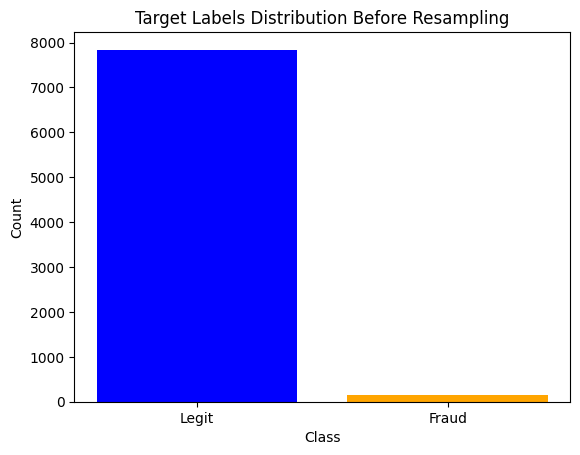

In [ ]:
import matplotlib.pyplot as plt

plt.bar(y.value_counts().index, y.value_counts().values, color=["blue", "orange"])
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Labels Distribution Before Resampling")
plt.show()

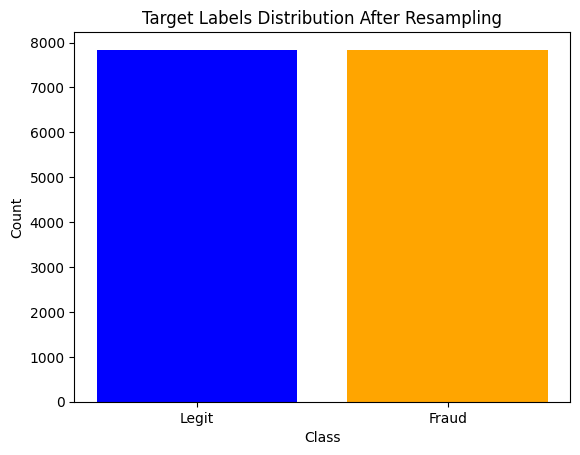

In [ ]:
plt.bar(y_resampled.value_counts().index, y_resampled.value_counts().values, color=["blue", "orange"])
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Labels Distribution After Resampling")
plt.show()

### Standardizing Numerical Features

Some machine learning models require numerical features to be on the same scale inorder to make proper predictions. As noted during exploration of the data some of the numerical features are on vastly different scales and are in need of standardization. Standard Scaler is used here to scale all of the numerical features to have a mean of zero and a unit of variance. This is done after train-test splitting to prevent __data leakage__.

## Model Building

It's time to try out a few models and see how they perform on the task. Let's start simple and increase model complexity as we go. Bellow a few popular machine learning classification algorithms are imported 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

### Evaluation Metrics

Given the imbalanced dataset, the suitable metric for evaluating the models is __average precision score__

__AP__ summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

$$ AP = \sum_{n} (R_n - R_{n-1})P_n $$

where $ P_n $ and $ R_n $ are the precision and recall at the nth threshold. This implementation is not interpolated and is different from computing the area under the precision-recall curve with the trapezoidal rule, which uses linear interpolation and can be too optimistic.

In [ ]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, precision_recall_curve, confusion_matrix

### Logistic Regression

Bellow a pipeline was created with StandardScaler, SMOTE oversampling and a LogisticRgression model. The model was trained using stratified cross-validation and achived a roc_aus score of 92%, average precision score of 46% and f1 score of 21%

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline

# Define components
smote = SMOTE(random_state=42)
scaler = StandardScaler()
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Make pipeline
log_reg_pipeline = ImbPipeline(
    steps= [
        ("scaler", scaler),
        ("smote", smote),
        ("model", log_reg)
    ]
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Run cv
results = cross_validate(
    log_reg_pipeline,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

for metric in scoring:
    print(f"{metric}: {results['test_' + metric].mean():.4f}")

roc_auc: 0.9231
pr_auc: 0.4603
f1: 0.2165


### K-Nearest Neighbors Classifier

Here the KNeighborsClassifier pipeline acived a roc_auc score of 84%, pr_auc score of 23%, and f1 score of 31%

In [ ]:
knn_clf = KNeighborsClassifier()

knn_clf_pipeline = ImbPipeline(
    steps = [
        ("scaler", scaler),
        ("smote", smote),
        ("model", knn_clf)
    ]
)

results = cross_validate(
    knn_clf_pipeline,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

for metric in scoring:
    print(f"{metric}: {results['test_' + metric].mean():.4f}")

roc_auc: 0.8438
pr_auc: 0.2342
f1: 0.3178


### Linear Support Vector Classifier

The pipeline performed the same as the LogisticRegression pipeline

In [ ]:
linear_svc = LinearSVC(random_state=42)

linear_svc_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", linear_svc)
    ]
)

results = cross_validate(
    linear_svc_pipeline,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

for metric in scoring:
    print(f"{metric}: {results['test_' + metric].mean():.4f}")

roc_auc: 0.9234
pr_auc: 0.4835
f1: 0.2120


### Random Forest Classifier

Bellow the model was trained using default parameters and achived a score of 100% on the training set and 50% on the validation set which clearly indicates that it's overfitting on the training set. Lowering model complexity during hyperparameter tuning may solve this issue

In [ ]:
forest_clf = RandomForestClassifier(random_state=42)

forest_clf_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", forest_clf)
    ]
)

results = cross_validate(
    forest_clf_pipeline,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

for metric in scoring:
    print(f"{metric}: {results['test_' + metric].mean():.4f}")

roc_auc: 0.9119
pr_auc: 0.3479
f1: 0.3878


## Hyperparameter Tuning

Let's try squeezing more performance form the models by tuning some of ther hyperparameters
by using random searching with cross-validation. Since this method picks random values for each hyperparameter from a predefined grid of values it doesn't guarnatee the optimal values but it's much faster than other alternatives.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

### Logistic Regression

In [ ]:
param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__fit_intercept": [True, False],
    "model__class_weight": [None, "balanced"],
}

rand_search = RandomizedSearchCV(
    log_reg_pipeline,
    param_distributions=param_dist,
    n_iter=20,                      
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__fit_intercept': [True, False], 'smote__k_neighbors': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [ ]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyperparameters: {best_prams}")
print(f"Best score: {best_score}")

Best hyperparameters: {'smote__sampling_strategy': 0.5, 'smote__k_neighbors': 3, 'model__fit_intercept': True, 'model__class_weight': 'balanced', 'model__C': 0.001}
Best score: 0.5034283768311354


### K-Nearest Neighbors Classifier

Bellow the `n_estimators` hyper parameter is tuned. After hyperparameter tuning the best model achived a score of 46% which is slightly better than before but is still bad.

In [ ]:
param_dist = {
    "model__n_neighbors": [20, 22, 24, 26, 28, 30],
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
}

rand_search = RandomizedSearchCV(
    knn_clf_pipeline,
    param_distributions=param_dist,
    n_iter=20,                      
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__n_neighbors': [20, 22, ...], 'smote__k_neighbors': [3, 5, ...], 'smote__sampling_strategy': [0.2, 0.5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [ ]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyperparameters: {best_prams}")
print(f"Best score: {best_score}")

Best hyperparameters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 5, 'model__n_neighbors': 30}
Best score: 0.4668858094944043


### Linear Support Vector Classifier

Bellow the `C` , `loss`, `fit_intercept` and  `class_weight` are tuned. After hyperparameter tuning the best model achived a score of 49% which is slightly better than before but still not good enough

In [ ]:
param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__C": [0.001, 0.01, 0.1, 1, 10, 20, 30, 40],
    "model__loss": ["hinge", "squared_hinge"],
    "model__fit_intercept": [True, False],
    "model__class_weight": [None, "balanced"]
}

rand_search = RandomizedSearchCV(
    linear_svc_pipeline,
    param_distributions=param_dist,
    n_iter=20,                      
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__fit_intercept': [True, False], 'model__loss': ['hinge', 'squared_hinge'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-val

In [ ]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best parameters: {best_prams}")
print(f"Best score: {best_score}")

Best parameters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 3, 'model__loss': 'squared_hinge', 'model__fit_intercept': True, 'model__class_weight': None, 'model__C': 0.1}
Best score: 0.4926592262841947


### Random Forest Classifer

Bellow the `n_estimators`, `max_depth`, `criterion`, `min_samples_leaf`, `min_samples_split`, `max_features` and `class_weight` hyperparameters are tuned. After hyperparameter tuning the best model achived a score of 68% which is highest of all models tested but is still somewhat low.

In [ ]:
param_dist = {
    "smote__k_neighbors":[3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__n_estimators": [50, 70, 90],
    "model__max_depth": [2, 4, 6],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__min_samples_leaf": [2, 4, 6],
    "model__min_samples_split": [2, 4, 6],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced", "balanced_subsample"]
}

rand_search = RandomizedSearchCV(
    forest_clf_pipeline,
    param_distributions=param_dist,
    n_iter=20,                      
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced', ...], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [2, 4, ...], 'model__max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the vario

In [ ]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best paramters: {best_prams}")
print(f"Best score: {best_score}")

Best paramters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 5, 'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 6, 'model__criterion': 'entropy', 'model__class_weight': None}
Best score: 0.5322356236698066
